# CO$_2$ - extend the latitudinal gradient principal components

Extend the latitudinal gradient's principal components back in time.
For CO$_2$, we do this by using a regression against emissions.

## Imports

In [1]:
from collections.abc import Iterator
from contextlib import contextmanager
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import numpy as np
import openscm_units
import pint
import pint_xarray
import primap2  # type: ignore
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.config
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.regressors
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

Quantity = pint.get_application_registry().Quantity  # type: ignore

In [3]:
QuantityOSCM = openscm_units.unit_registry.Quantity

## Define branch this notebook belongs to

In [4]:
step: str = "calculate_co2_monthly_fifteen_degree_pieces"

## Parameters

In [5]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "only"  # config ID to select for this branch

In [6]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "only"


## Load config

In [7]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

config_retrieve_misc = get_config_for_step_id(config=config, step="retrieve_misc_data", step_config_id="only")

## Action

### Helper functions

In [8]:
@contextmanager
def axes_vertical_split(
    ncols: int = 2,
) -> Iterator[tuple[matplotlib.axes.Axes, matplotlib.axes.Axes]]:
    """Get two split axes, formatting after exiting the context"""
    fig, axes = plt.subplots(ncols=ncols)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    yield (axes[0], axes[1])

    plt.tight_layout()
    plt.show()

### Load data

In [9]:
global_annual_mean_obs_network: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_global_annual_mean_file
).pint.quantify()
global_annual_mean_obs_network

Magnitude,[340.41841524741864 340.8898303109085 342.39885069815256 344.06265671648015 345.5184583462482 347.00121114937195 348.7715769996939 351.2754612537245 352.8699075105913 354.0914861354658 355.40912368466803 356.30032252212226 357.0166270959333 358.370066213528 360.33215202440806 362.12592764458645 363.35349381242787 366.07816847298403 367.9341462761768 369.2326123405019 370.80002275769425 372.90811111454974 375.4381052498998 377.09990751380724 379.01912894024855 381.1603389630507 382.76298465768406 384.927932382924 386.4896998114968 388.90119278134506 391.0921633133191 393.2440375168851 395.94573536207764 397.8326799296954 400.1363097826533 403.2492569508209 405.2739484544132 407.76275380672223 410.3671897526088 412.8736931180183 415.12597139417943 417.32025724171285 419.6866820727719]
Units,ppm


In [10]:
lat_grad_eofs_obs_network = xr.load_dataset(
    config_step.observational_network_latitudinal_gradient_eofs_file
).pint.quantify()
lat_grad_eofs_obs_network

Magnitude,[[0.3398549235667994 -0.2279518542202384] [0.3280249642550779 -0.21667814452529127] [0.3240928653441622 -0.11290118149536105] [0.29643637000091805 0.001162345511583901] [0.23146558727475253 0.11844135697646926] [0.13696989509884952 0.20319759722792471] [-0.0713614960427211 0.174397046007536] [-0.19958442222557185 0.2667222315807009] [-0.4242643004612816 -0.7221899732016387] [-0.34060660505423995 -0.12186793264806786] [-0.3042778672164788 0.10852869951757736] [-0.279510277857286 0.42811117709708046]]
Units,ppm
Magnitude,[[-3.4078559757362656 1.3728705809672521] [-3.0718928926968796 1.080944204165597] [-2.9148521501787985 0.8886287181528333] [-3.389224313579394 0.9345832823250398] [-3.5797363227564327 0.7671336820172274] [-4.222134676615504 0.9441732209243293] [-3.220898661371553 1.0383549537628198] [-4.531214183272495 1.2310945088122962] [-4.951772992913496 1.5677083013287625] [-4.538514865693663 1.2804213657427] [-5.173706470749861 1.2338640592569938] [-4.273103707637795 0.8496375674941062] [-3.965108611258437 0.6241795767995816] [-5.042210471999207 0.459726569836758] [-5.111975184252345 0.6019809645460302] [-6.008421371790536 0.3424537649315777] [-5.36418297137572 0.35681607952608585] [-5.492211705600382 0.6138119587480596] [-6.070957788177195 -0.059653030130348075] [-6.392679427617976 -0.16228148585739732] [-6.3834000533068505 -0.45827770761568964] [-6.116260991320756 -0.5048325325708336] [-6.957893832419071 -0.3820759214669319] [-6.347658054708406 -0.6213875357467776] [-6.846471859965717 -0.7524881659932885] [-7.551205937839135 -0.7686209282608008] [-6.705257602735117 -1.3241931223382695] [-7.301377545919926 -1.1342376935890761] [-6.888449225143301 -1.0418218293248094] [-8.483601605052062 -1.7004306283376365] [-8.614714835190084 -1.1307825171650858] [-8.537130218880705 -0.6086678103421533] [-8.305819625835335 -0.2548015726615268] [-8.226966271201903 -0.3595563980313965] [-7.689675133590265 -0.10292169544148298] [-7.679706725149857 0.06957983323397103] [-8.859902121453993 0.11975459474699837] [-8.09737915282875 0.08563958690373405] [-7.8006602845076145 0.37368035213824286] [-8.101679825965508 0.5991512005844014] [-9.1172598635361 0.14862754294515435] [-8.939469815800466 0.1303478895442889] [-8.590944383639819 0.4360138174509567]]
Units,dimensionless


### Define some important constants

In [11]:
if not config.ci:
    out_years = np.arange(1, lat_grad_eofs_obs_network["year"].max() + 1)

else:
    out_years = np.arange(1750, lat_grad_eofs_obs_network["year"].max() + 1)

out_years

array([   1,    2,    3, ..., 2021, 2022, 2023])

In [12]:
obs_network_years = lat_grad_eofs_obs_network["year"]
obs_network_years

<xarray.DataArray 'year' (year: 43)> Size: 344B
array([1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019, 2020, 2021, 2022, 2023])
Coordinates:
  * year     (year) int64 344B 1981 1982 1983 1984 1985 ... 2020 2021 2022 2023

In [13]:
use_extensions_years = np.setdiff1d(out_years, obs_network_years)
use_extensions_years

array([   1,    2,    3, ..., 1978, 1979, 1980])

### Extend PC one

(Zero-indexing, hence this is the second PC)

This is returned to zero in 1850 from the start of the observational network period.

In [14]:
# Quick assertion that things are as expected
exp_n_eofs = 2
if len(lat_grad_eofs_obs_network["eof"]) != exp_n_eofs:
    raise AssertionError("Rethink")

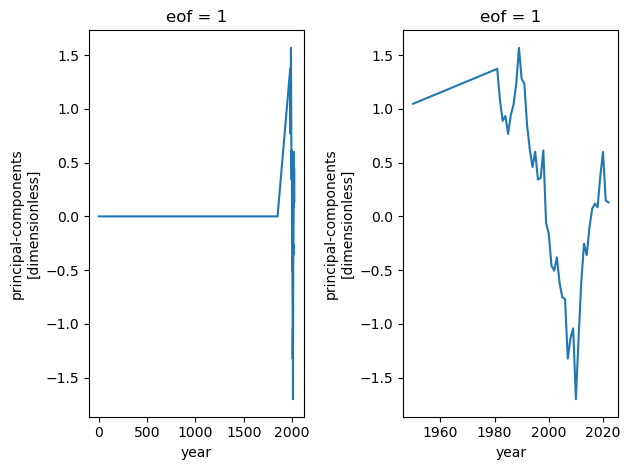

<xarray.DataArray 'principal-components' (year: 2023)> Size: 16kB
array([0.        , 0.        , 0.        , ..., 0.14862754, 0.13034789,
       0.43601382])
Coordinates:
    eof      int64 8B 1
  * year     (year) int64 16kB 1 2 3 4 5 6 7 ... 2018 2019 2020 2021 2022 2023
Attributes:
    description:  Principal components for the latitudinal gradient EOFs
    units:        dimensionless

In [15]:
pc1 = lat_grad_eofs_obs_network["principal-components"].sel(eof=1).copy()

zero_year = 1850
tmp = pc1.sel(year=pc1["year"][0])
tmp = tmp.assign_coords(year=zero_year)
tmp.values = 0.0

allyears_pc1 = (
    xr.concat([tmp, pc1], "year").pint.dequantify().interp(year=out_years, kwargs={"fill_value": 0})
)

with axes_vertical_split() as axes:
    allyears_pc1.plot(ax=axes[0])
    allyears_pc1.sel(year=range(1950, 2023)).plot(ax=axes[1])

allyears_pc1

### Extend PC zero

(Zero-indexing, hence this is the first PC)

This happens in a few steps.

#### Use a regression against emissions to fill in the gap

There is a gap between the observational network period
and the optimised ice core period.
We fill this using a regression against emissions.

In [16]:
primap_full = primap2.open_dataset(
    config_retrieve_misc.primap.raw_dir / config_retrieve_misc.primap.download_url.url.split("/")[-1]
)

primap_fossil_co2_emissions = (
    local.xarray_time.convert_time_to_year_month(primap_full)
    .sel(
        **{
            "category (IPCC2006_PRIMAP)": "M.0.EL",
            "scenario (PRIMAP-hist)": "HISTTP",
            "area (ISO3)": "EARTH",
            "month": 1,
        }
    )[config_step.gas.upper()]
    .squeeze()
    .pint.to("GtCO2 / yr")
    .reset_coords(drop=True)
)

primap_fossil_co2_emissions

<xarray.DataArray 'CO2' (year: 273)> Size: 2kB
<Quantity([3.4073832e-04 9.6984417e-03 9.7025075e-03 9.7027925e-03 9.7068583e-03
 9.7109241e-03 1.0376645e-02 1.0380711e-02 1.0384777e-02 1.0388842e-02
 1.0389127e-02 1.1376241e-02 1.1380325e-02 1.1384408e-02 1.1388491e-02
 1.1392575e-02 1.2704845e-02 1.2708928e-02 1.2713012e-02 1.2717095e-02
 1.2721179e-02 1.4101523e-02 1.4105626e-02 1.4109728e-02 1.4113830e-02
 1.4117933e-02 1.5573895e-02 1.5628849e-02 1.5685588e-02 1.5744111e-02
 1.5808200e-02 1.7714731e-02 1.7783007e-02 1.7858099e-02 1.7932445e-02
 1.8017914e-02 2.0450041e-02 2.0537273e-02 2.0623760e-02 2.0717062e-02
 2.0813400e-02 2.3219134e-02 2.3836942e-02 2.3954485e-02 2.4018939e-02
 2.4134500e-02 2.5340076e-02 2.6630737e-02 2.7777715e-02 2.9273507e-02
 3.1119071e-02 3.1085445e-02 3.8825426e-02 4.1199491e-02 4.2196440e-02
 4.3187372e-02 4.4852436e-02 4.6905925e-02 4.5026975e-02 4.5047040e-02
 4.5524845e-02 4.7787255e-02 4.9281103e-02 4.9483564e-02 5.0428846e-02
 5.1875025e-02 5.6300101e-02 5.8214956e-02 5.8417909e-02 5.8571955e-02
 5.9401445e-02 6.0194704e-02 6.2306749e-02 6.5497425e-02 6.7528034e-02
 6.9946081e-02 7.0643181e-02 7.5512320e-02 7.6277861e-02 7.5972409e-02
 9.3827267e-02 8.8868845e-02 8.9500810e-02 9.1354086e-02 9.3380665e-02
 9.5573156e-02 1.1064282e-01 1.1076929e-01 1.1446275e-01 1.1823081e-01
 1.2607868e-01 1.3022757e-01 1.3767572e-01 1.4095455e-01 1.5016016e-01
 1.6502674e-01 1.6859037e-01 1.8426014e-01 1.8530010e-01 1.9540907e-01
...
 4.0178347e+00 3.9575337e+00 4.3365630e+00 4.3194887e+00 4.6465560e+00
 4.2995318e+00 3.8463544e+00 3.4767026e+00 3.6579562e+00 3.9811307e+00
 4.1837368e+00 4.5848719e+00 4.9162070e+00 4.6378866e+00 4.9153839e+00
 5.3032585e+00 5.4198036e+00 5.4345941e+00 5.6244211e+00 5.5692734e+00
 4.6638667e+00 5.1433587e+00 5.6972281e+00 5.9809029e+00 5.7798409e+00
 6.1913917e+00 6.6523339e+00 6.7354908e+00 6.9216636e+00 7.0902423e+00
 7.7502681e+00 8.2417724e+00 8.5145835e+00 8.7935488e+00 9.2689706e+00
 9.7744888e+00 9.7781022e+00 1.0124486e+01 1.0706781e+01 1.1223092e+01
 1.1735529e+01 1.2273109e+01 1.2587579e+01 1.3256308e+01 1.4125150e+01
 1.5504022e+01 1.6017273e+01 1.6747803e+01 1.7617815e+01 1.7542374e+01
 1.7503871e+01 1.8464820e+01 1.8948585e+01 1.9413063e+01 1.9988710e+01
 1.9901812e+01 1.9385261e+01 1.9221707e+01 1.9450183e+01 2.0089044e+01
 2.0774490e+01 2.1061256e+01 2.1610561e+01 2.2406332e+01 2.2771294e+01
 2.2257214e+01 2.2825785e+01 2.2521264e+01 2.2700882e+01 2.2793936e+01
 2.3264723e+01 2.3856706e+01 2.4028508e+01 2.3941424e+01 2.4471724e+01
 2.5199610e+01 2.5303098e+01 2.5853170e+01 2.7219090e+01 2.8221375e+01
 2.9135728e+01 3.0153193e+01 3.1005158e+01 3.1798047e+01 3.1372653e+01
 3.3023148e+01 3.4180416e+01 3.4695295e+01 3.4886516e+01 3.5268996e+01
 3.5284285e+01 3.5321849e+01 3.5931396e+01 3.6754760e+01 3.7182919e+01
 3.5577220e+01 3.7454981e+01 3.7704548e+01], 'gigatCO2 / yr')>
Coordinates:
  * year     (year) int64 2kB 1750 1751 1752 1753 1754 ... 2019 2020 2021 2022
Attributes:
    entity:   CO2

In [17]:
regression_years = np.intersect1d(lat_grad_eofs_obs_network["year"], primap_fossil_co2_emissions["year"])
regression_years

array([1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002,
       2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [18]:
primap_regression_data = primap_fossil_co2_emissions.sel(year=regression_years)
primap_regression_data

Magnitude,[19.385261000000003 19.221707000000002 19.450183000000003 20.089044000000005 20.774490000000004 21.061256000000004 21.610561000000004 22.406332000000003 22.771294000000005 22.257214000000005 22.825785000000003 22.521264000000002 22.700882000000004 22.793936000000002 23.264723000000004 23.856706000000003 24.028508000000006 23.941424000000005 24.471724000000005 25.199610000000003 25.303098000000006 25.853170000000006 27.219090000000005 28.221375000000005 29.135728000000004 30.153193000000005 31.005158000000005 31.798047000000004 31.372653000000007 33.023148000000006 34.18041600000001 34.69529500000001 34.88651600000001 35.26899600000001 35.284285000000004 35.32184900000001 35.93139600000001 36.754760000000005 37.182919000000005 35.577220000000004 37.454981000000004 37.70454800000001]
Units,gigatCO2/yr


In [19]:
pc0_obs_network_regression = lat_grad_eofs_obs_network["principal-components"].sel(
    eof=0, year=regression_years
)
pc0_obs_network_regression

Magnitude,[-3.4078559757362656 -3.0718928926968796 -2.9148521501787985 -3.389224313579394 -3.5797363227564327 -4.222134676615504 -3.220898661371553 -4.531214183272495 -4.951772992913496 -4.538514865693663 -5.173706470749861 -4.273103707637795 -3.965108611258437 -5.042210471999207 -5.111975184252345 -6.008421371790536 -5.36418297137572 -5.492211705600382 -6.070957788177195 -6.392679427617976 -6.3834000533068505 -6.116260991320756 -6.957893832419071 -6.347658054708406 -6.846471859965717 -7.551205937839135 -6.705257602735117 -7.301377545919926 -6.888449225143301 -8.483601605052062 -8.614714835190084 -8.537130218880705 -8.305819625835335 -8.226966271201903 -7.689675133590265 -7.679706725149857 -8.859902121453993 -8.09737915282875 -7.8006602845076145 -8.101679825965508 -9.1172598635361 -8.939469815800466]
Units,dimensionless


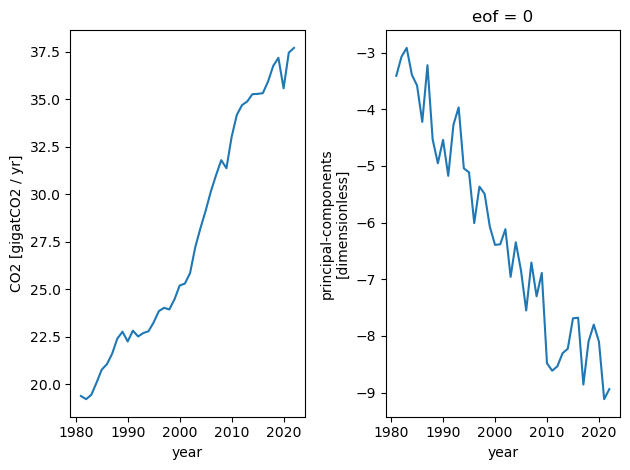

In [20]:
with axes_vertical_split() as axes:
    primap_regression_data.plot(ax=axes[0])
    pc0_obs_network_regression.plot(ax=axes[1])

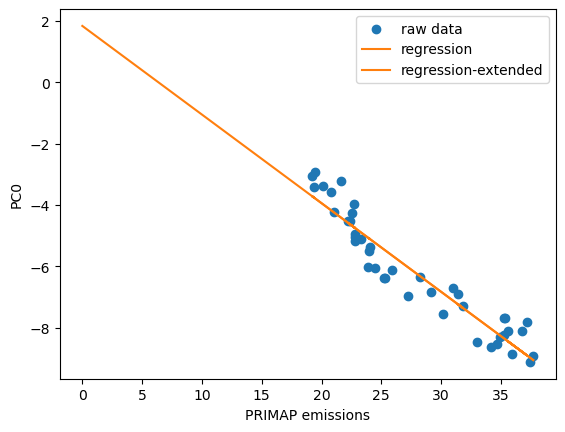

In [21]:
x = QuantityOSCM(primap_regression_data.data.m, str(primap_regression_data.data.units))
A = np.vstack([x.m, np.ones(x.size)]).T
y = QuantityOSCM(pc0_obs_network_regression.data.m, str(pc0_obs_network_regression.data.units))

res = np.linalg.lstsq(A, y.m, rcond=None)
m, c = res[0]
m = QuantityOSCM(m, (y / x).units)
c = QuantityOSCM(c, y.units)

latitudinal_gradient_pc0_co2_fossil_emissions_regression = local.regressors.LinearRegressionResult(m=m, c=c)

fig, ax = plt.subplots()
ax.scatter(x.m, y.m, label="raw data")
ax.plot(x.m, (m * x + c).m, color="tab:orange", label="regression")
ax.plot(
    np.hstack([0, x.m]),
    (m * np.hstack([0, x]) + c).m,
    color="tab:orange",
    label="regression-extended",
)
ax.set_ylabel("PC0")
ax.set_xlabel("PRIMAP emissions")
ax.legend()

Extend PRIMAP emissions back to year 1, assuming constant before 1750.

In [22]:
primap_fossil_co2_emissions_extension_years = np.union1d(
    np.setdiff1d(out_years, pc0_obs_network_regression["year"]),
    primap_fossil_co2_emissions["year"],
)
# Ensure we only extend backwards
primap_fossil_co2_emissions_extension_years = primap_fossil_co2_emissions_extension_years[
    np.where(primap_fossil_co2_emissions_extension_years <= primap_fossil_co2_emissions["year"].max().values)
]

primap_fossil_co2_emissions_extension_years

array([   1,    2,    3, ..., 2020, 2021, 2022])

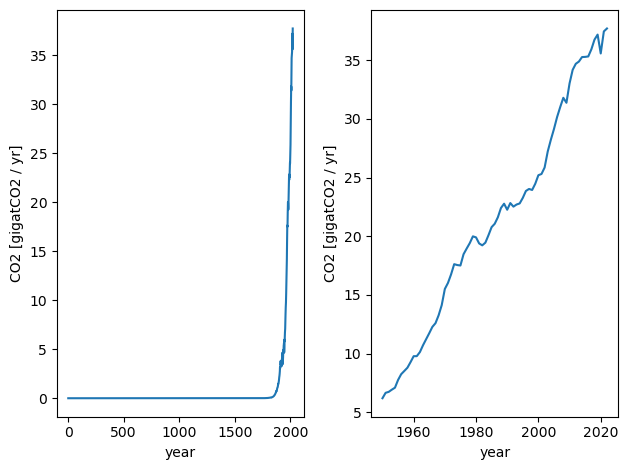

<xarray.DataArray 'CO2' (year: 2022)> Size: 16kB
array([3.4073832e-04, 3.4073832e-04, 3.4073832e-04, ..., 3.5577220e+01,
       3.7454981e+01, 3.7704548e+01])
Coordinates:
  * year     (year) int64 16kB 1 2 3 4 5 6 7 ... 2017 2018 2019 2020 2021 2022
Attributes:
    entity:   CO2
    units:    gigatCO2 / yr

In [23]:
primap_fossil_co2_emissions_extended = primap_fossil_co2_emissions.copy()
primap_fossil_co2_emissions_extended = primap_fossil_co2_emissions_extended.pint.dequantify().interp(
    year=primap_fossil_co2_emissions_extension_years,
    kwargs={"fill_value": primap_fossil_co2_emissions.data[0].m},
)

with axes_vertical_split() as axes:
    primap_fossil_co2_emissions_extended.plot(ax=axes[0])
    primap_fossil_co2_emissions_extended.sel(year=range(1950, 2023)).plot(ax=axes[1])

primap_fossil_co2_emissions_extended

In [24]:
years_to_fill_with_regression = np.setdiff1d(
    primap_fossil_co2_emissions_extended["year"],
    pc0_obs_network_regression["year"],
)

years_to_fill_with_regression

array([   1,    2,    3, ..., 1978, 1979, 1980])

In [25]:
pc0_emissions_extended = (
    m
    * primap_fossil_co2_emissions_extended.sel(year=years_to_fill_with_regression).pint.quantify(
        unit_registry=openscm_units.unit_registry
    )
    + c
)
pc0_emissions_extended = pc0_emissions_extended.assign_coords(eof=0)
pc0_emissions_extended = pc0_emissions_extended.assign_coords(eof=0)
pc0_emissions_extended

Magnitude,[1.8369526538438787 1.8369526538438787 1.8369526538438787 ... -3.7715019970865225 -3.9378099497231833 -3.9127045839899814]
Units,dimensionless


#### Concatenate the pieces of PC0

Join:

- extended based on regression with emissions
- raw values derived from the observational network

In [26]:
pc0_obs_network_raw_years = np.setdiff1d(
    lat_grad_eofs_obs_network["principal-components"].sel(
        eof=0,
    )["year"],
    pc0_obs_network_regression["year"],
)

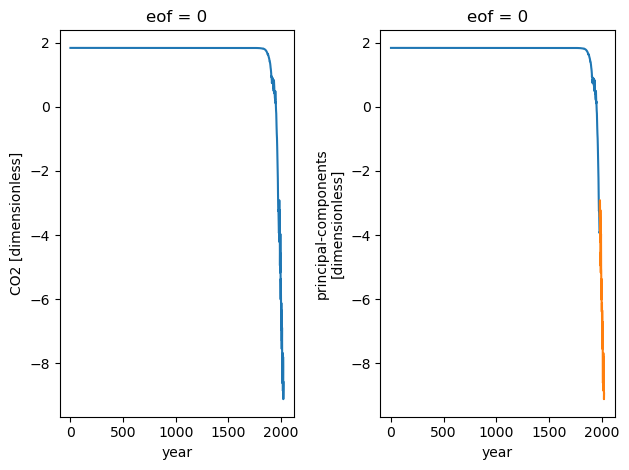

Magnitude,[1.8369526538438787 1.8369526538438787 1.8369526538438787 ... -9.1172598635361 -8.939469815800466 -8.590944383639819]
Units,dimensionless


In [27]:
allyears_pc0 = xr.concat(
    [
        pc0_emissions_extended,
        pc0_obs_network_regression,
        lat_grad_eofs_obs_network["principal-components"].sel(eof=0, year=pc0_obs_network_raw_years),
    ],
    "year",
)

with axes_vertical_split() as axes:
    allyears_pc0.plot(ax=axes[0])

    pc0_emissions_extended.plot(ax=axes[1])
    pc0_obs_network_regression.plot(ax=axes[1])

allyears_pc0

### Join the PCs back together

In [28]:
allyears_pcs = xr.concat([allyears_pc0, allyears_pc1], "eof").pint.dequantify().pint.quantify()
allyears_pcs

Magnitude,[[1.8369526538438787 1.8369526538438787 1.8369526538438787 ... -9.1172598635361 -8.939469815800466 -8.590944383639819] [0.0 0.0 0.0 ... 0.14862754294515435 0.1303478895442889 0.4360138174509567]]
Units,dimensionless


### Join PCs and EOFs back together

In [29]:
allyears_pcs.name = "principal-components"
out = xr.merge([allyears_pcs, lat_grad_eofs_obs_network["eofs"]])
out

Magnitude,[[1.8369526538438787 1.8369526538438787 1.8369526538438787 ... -9.1172598635361 -8.939469815800466 -8.590944383639819] [0.0 0.0 0.0 ... 0.14862754294515435 0.1303478895442889 0.4360138174509567]]
Units,dimensionless
Magnitude,[[0.3398549235667994 -0.2279518542202384] [0.3280249642550779 -0.21667814452529127] [0.3240928653441622 -0.11290118149536105] [0.29643637000091805 0.001162345511583901] [0.23146558727475253 0.11844135697646926] [0.13696989509884952 0.20319759722792471] [-0.0713614960427211 0.174397046007536] [-0.19958442222557185 0.2667222315807009] [-0.4242643004612816 -0.7221899732016387] [-0.34060660505423995 -0.12186793264806786] [-0.3042778672164788 0.10852869951757736] [-0.279510277857286 0.42811117709708046]]
Units,ppm


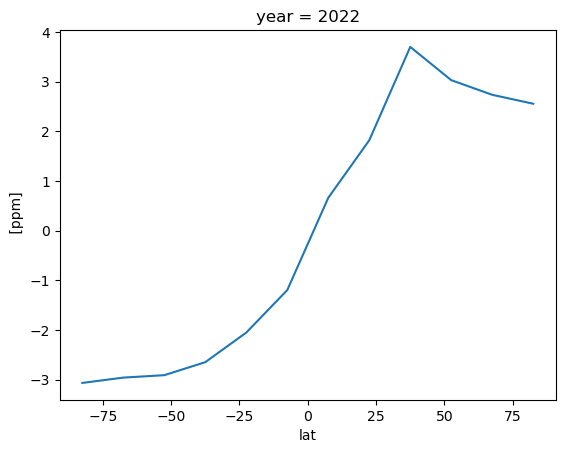

In [30]:
(out["principal-components"] @ out["eofs"]).sel(year=2022).plot()  # type: ignore

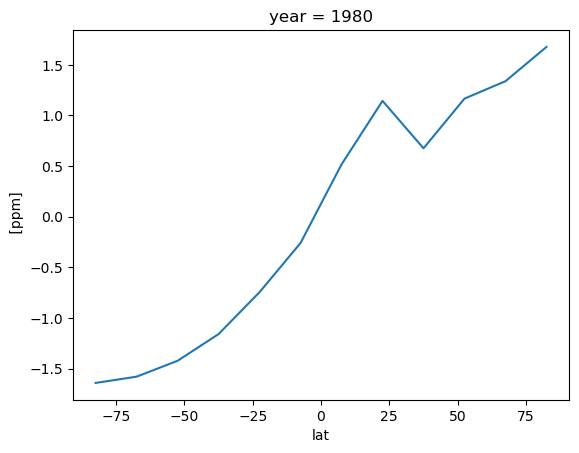

In [31]:
(out["principal-components"] @ out["eofs"]).sel(year=1980).plot()  # type: ignore

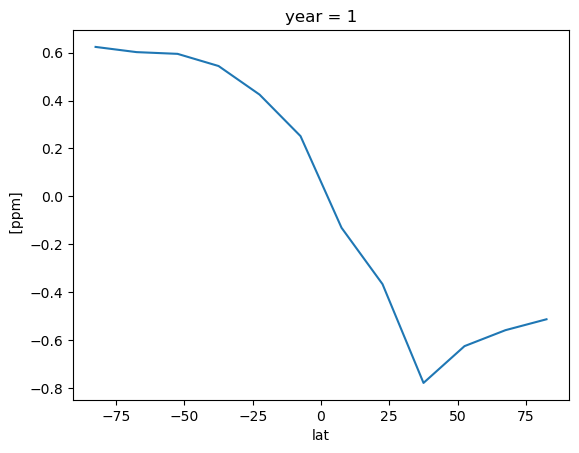

In [32]:
(out["principal-components"] @ out["eofs"]).sel(year=out["year"].min()).plot()  # type: ignore

Quick check that our output matches the observational network in the years they overlap.

In [33]:
xr.testing.assert_allclose(
    (out["principal-components"] @ out["eofs"]).sel(year=lat_grad_eofs_obs_network["year"]),
    lat_grad_eofs_obs_network["principal-components"] @ lat_grad_eofs_obs_network["eofs"],
)

## Save

In [34]:
config_step.latitudinal_gradient_allyears_pcs_eofs_file.parent.mkdir(exist_ok=True, parents=True)
out.pint.dequantify().to_netcdf(config_step.latitudinal_gradient_allyears_pcs_eofs_file)
out

Magnitude,[[1.8369526538438787 1.8369526538438787 1.8369526538438787 ... -9.1172598635361 -8.939469815800466 -8.590944383639819] [0.0 0.0 0.0 ... 0.14862754294515435 0.1303478895442889 0.4360138174509567]]
Units,dimensionless
Magnitude,[[0.3398549235667994 -0.2279518542202384] [0.3280249642550779 -0.21667814452529127] [0.3240928653441622 -0.11290118149536105] [0.29643637000091805 0.001162345511583901] [0.23146558727475253 0.11844135697646926] [0.13696989509884952 0.20319759722792471] [-0.0713614960427211 0.174397046007536] [-0.19958442222557185 0.2667222315807009] [-0.4242643004612816 -0.7221899732016387] [-0.34060660505423995 -0.12186793264806786] [-0.3042778672164788 0.10852869951757736] [-0.279510277857286 0.42811117709708046]]
Units,ppm


In [35]:
config_step.latitudinal_gradient_pc0_co2_fossil_emissions_regression_file.parent.mkdir(
    exist_ok=True, parents=True
)
with open(config_step.latitudinal_gradient_pc0_co2_fossil_emissions_regression_file, "w") as fh:
    fh.write(local.config.converter_yaml.dumps(latitudinal_gradient_pc0_co2_fossil_emissions_regression))

latitudinal_gradient_pc0_co2_fossil_emissions_regression

LinearRegressionResult(m=<Quantity(-0.2889061397638848, 'yr / gigatCO2')>, c=<Quantity(1.8370510952365795, 'dimensionless')>)